# NB2 - From light to haemoglobin

*fNIRS block course - accompanies slides 9-13*

NB1 showed the **raw light intensity** and the systemic physiology it contains.
Here we turn that intensity into the quantities we actually care about -
changes in **oxy-** and **deoxy-haemoglobin** concentration (HbO / HbR) - and
clean the signal along the way.

**Pipeline**
1. Intensity -> **optical density** (OD)
2. **Signal quality**: scalp-coupling index (SCI) and SNR -> prune bad channels
3. **Motion artifacts**: detect and correct with **TDDR**
4. **Band-pass filter** to the haemodynamic band
5. OD -> **HbO / HbR** via the **modified Beer-Lambert law**

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

import cedalion
import cedalion.io
import cedalion.nirs
import cedalion.nirs.cw as cw
import cedalion.dataclasses as cdc
import cedalion.sigproc.quality as quality
import cedalion.sigproc.motion as motion
import cedalion.sigproc.frequency as frequency
from cedalion import units

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

### Load the recording

(Same helpers as NB1 - each notebook is self-contained.)

In [2]:
def load_recording(path):
    rec = cedalion.io.read_snirf(path)[0]
    amp = rec["amp"]
    amp.time.attrs["units"] = "s"
    return rec, amp


def load_montage(path):
    with h5py.File(path, "r") as h:
        pr = h["nirs/probe"]
        src_labels = [s.decode() for s in np.array(pr["sourceLabels"])]
        det_labels = [d.decode() for d in np.array(pr["detectorLabels"])]
        src_pos = np.array(pr["sourcePos2D"])
        det_pos = np.array(pr["detectorPos2D"])
    labels = np.array(src_labels + det_labels)
    types = ([cdc.PointType.SOURCE] * len(src_labels)
             + [cdc.PointType.DETECTOR] * len(det_labels))
    pos = np.vstack([
        np.column_stack([src_pos, np.zeros(len(src_pos))]),
        np.column_stack([det_pos, np.zeros(len(det_pos))]),
    ])
    return xr.DataArray(
        pos, dims=["label", "pos"],
        coords={"label": ("label", labels), "type": ("label", types)},
        attrs={"units": "mm"},
    ).pint.quantify()

In [3]:
def find_data(subdir="resting_state_1"):
    """Locate the dataset folder. Download it from the NITRC links in the
    README and extract into ./data/ so you have data/resting_state_1/."""
    here = os.getcwd()
    for c in [os.path.join(here, "data", subdir),
              os.path.join(here, "..", "data", subdir),
              os.path.join(here, subdir),
              os.path.join(here, "..", subdir)]:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError(
        f"'{subdir}' not found. See the README: download the data from NITRC "
        f"and extract it into the data/ folder (data/{subdir}/).")

DATA = find_data("resting_state_1")
SUBJECT = "Subj33"
snirf_file = os.path.join(DATA, SUBJECT, "resting.snirf")

rec, amp = load_recording(snirf_file)
geo3d = load_montage(snirf_file)
fs = float(1.0 / np.median(np.diff(amp.time.values)))
print(f"{amp.sizes['channel']} channels, {fs:.0f} Hz, "
      f"{amp.time.values[-1]:.0f} s, wavelengths {list(amp.wavelength.values)} nm")

34 channels, 50 Hz, 302 s, wavelengths [np.float64(690.0), np.float64(830.0)] nm

## Step 1 - Optical density

The modified Beer-Lambert law works with **optical density** (OD), the negative
log-ratio of intensity to its baseline (temporal mean):

$$\Delta \text{OD}(t) = -\ln \frac{I(t)}{I_0}$$

`cedalion.nirs.cw.int2od` does exactly this. OD is dimensionless and centred on
zero - the heartbeat ripple is now clearly visible.

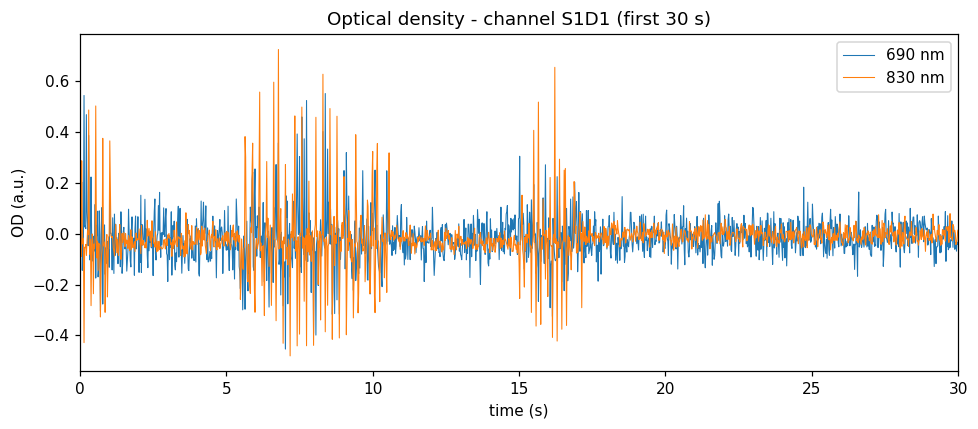

In [4]:
od = cw.int2od(amp)

ch = "S1D1"
fig, ax = plt.subplots()
for wl in od.wavelength.values:
    ax.plot(od.time.values, od.sel(channel=ch, wavelength=wl).values,
            lw=0.7, label=f"{int(wl)} nm")
ax.set_xlim(0, 30)
ax.set_xlabel("time (s)"); ax.set_ylabel("OD (a.u.)")
ax.set_title(f"Optical density - channel {ch} (first 30 s)")
ax.legend(); plt.tight_layout(); plt.show()

## Step 2 - Signal quality

Not every channel is usable: an optode may couple poorly to the scalp (hair,
movement). Two common metrics:

- **SCI** (scalp-coupling index): how strongly the cardiac pulse is shared
  between the two wavelengths in a channel - high SCI = good optical contact.
- **SNR**: mean amplitude relative to its standard deviation.

We compute both, reduce them to one verdict per channel, and **prune** the bad
ones with `quality.prune_ch`.

kept 13 / 34 channels

dropped:

['S1D1', 'S1D5', 'S1D6', 'S2D2', 'S2D6', 'S2D7', 'S3D3', 'S3D7', 'S3D8', 'S4D5', 'S4D10', 'S6D6', 'S6D7', 'S6D12', 'S7D7', 'S7D8', 'S7D13', 'S7D18', 'S7D19', 'S8D14', 'S8D19']

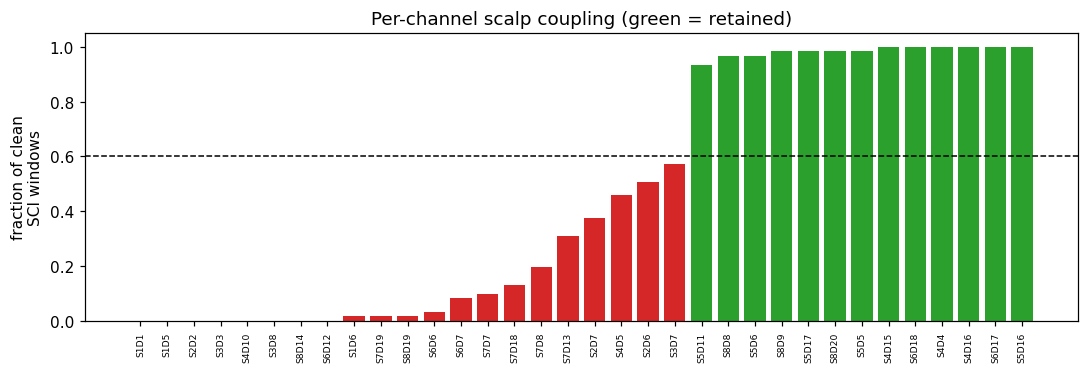

In [5]:
sci, sci_mask = quality.sci(amp, window_length=5 * units.s, sci_thresh=0.7)
snr, snr_mask = quality.snr(amp, snr_thresh=2.0)

# reduce to one boolean per channel
sci_per_ch = (sci_mask.mean("time") > 0.6)          # >60% of windows clean
snr_per_ch = snr_mask.all("wavelength")             # good at both wavelengths

amp_clean, dropped = quality.prune_ch(
    amp, [sci_per_ch, snr_per_ch], operator="all")
print(f"kept {amp_clean.sizes['channel']} / {amp.sizes['channel']} channels")
print("dropped:", list(dropped))

# visualise SCI clean-fraction per channel
frac = sci_mask.mean("time").values
order = np.argsort(frac)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(frac)), frac[order],
       color=["tab:green" if f > 0.6 else "tab:red" for f in frac[order]])
ax.axhline(0.6, color="k", ls="--", lw=1)
ax.set_xticks(range(len(frac)))
ax.set_xticklabels(amp.channel.values[order], rotation=90, fontsize=6)
ax.set_ylabel("fraction of clean\nSCI windows")
ax.set_title("Per-channel scalp coupling (green = retained)")
plt.tight_layout(); plt.show()

## Step 3 - Motion artifacts and TDDR

Head movement produces sharp spikes or steps in OD. **TDDR** (Temporal
Derivative Distribution Repair, Fishburn 2019) removes them without needing any
tuning parameters.

This resting recording is fairly motion-free, so to *show* what TDDR does we add
an **artificial motion spike** to one channel, then correct it.

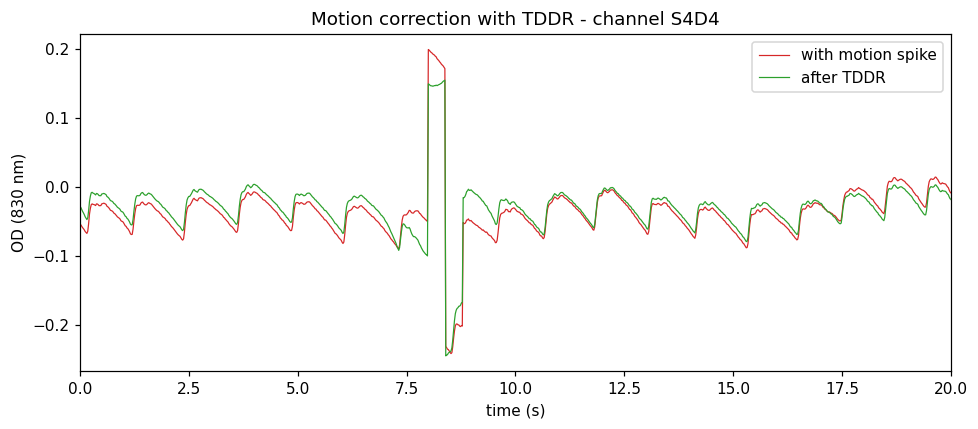

In [6]:
od_clean = cw.int2od(amp_clean)

# inject an artificial motion spike to demonstrate TDDR
demo_ch = str(amp_clean.channel.values[0])   # a channel that survived pruning
od_demo = od_clean.copy()
t = od_demo.time.values
spike = np.zeros_like(t)
i0 = int(8 * fs)
spike[i0:i0 + int(0.4 * fs)] += 0.25       # sharp positive step
spike[i0 + int(0.4 * fs):i0 + int(0.8 * fs)] -= 0.15
for wl in od_demo.wavelength.values:
    od_demo.loc[dict(channel=demo_ch, wavelength=wl)] = \
        od_demo.sel(channel=demo_ch, wavelength=wl).values + spike

od_corr = motion.tddr(od_demo)

fig, ax = plt.subplots()
ax.plot(t, od_demo.sel(channel=demo_ch, wavelength=830.0).values,
        lw=0.8, color="tab:red", label="with motion spike")
ax.plot(t, od_corr.sel(channel=demo_ch, wavelength=830.0).values,
        lw=0.8, color="tab:green", label="after TDDR")
ax.set_xlim(0, 20)
ax.set_xlabel("time (s)"); ax.set_ylabel("OD (830 nm)")
ax.set_title(f"Motion correction with TDDR - channel {demo_ch}")
ax.legend(); plt.tight_layout(); plt.show()

## Step 4 - Band-pass filtering

The neural haemodynamic response lives roughly in **0.01-0.5 Hz**. A band-pass
filter removes the slow drift (below) and the cardiac/respiration components
(above), keeping the band where the evoked response sits.
`frequency.freq_filter` applies a Butterworth filter.

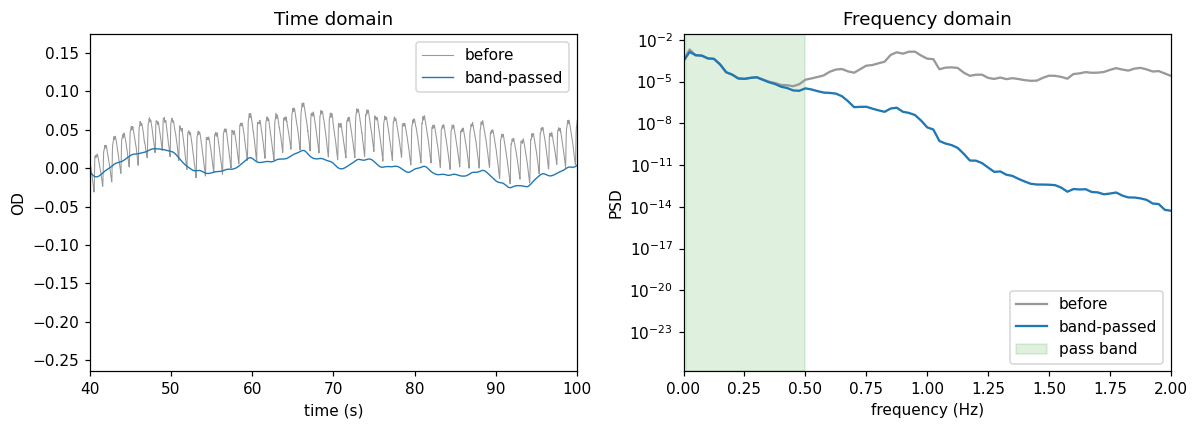

In [7]:
od_filt = frequency.freq_filter(od_corr, 0.01 * units.Hz, 0.5 * units.Hz,
                                butter_order=4)

sig0 = od_corr.sel(channel=demo_ch, wavelength=830.0).values
sig1 = od_filt.sel(channel=demo_ch, wavelength=830.0).values
f0, p0 = welch(sig0 - sig0.mean(), fs=fs, nperseg=int(fs * 40))
f1, p1 = welch(sig1 - sig1.mean(), fs=fs, nperseg=int(fs * 40))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(t, sig0, lw=0.7, color="0.6", label="before")
a1.plot(t, sig1, lw=0.9, color="tab:blue", label="band-passed")
a1.set_xlim(40, 100); a1.set_xlabel("time (s)"); a1.set_ylabel("OD")
a1.set_title("Time domain"); a1.legend()
a2.semilogy(f0, p0, color="0.6", label="before")
a2.semilogy(f1, p1, color="tab:blue", label="band-passed")
a2.axvspan(0.01, 0.5, color="tab:green", alpha=0.15, label="pass band")
a2.set_xlim(0, 2.0); a2.set_xlabel("frequency (Hz)"); a2.set_ylabel("PSD")
a2.set_title("Frequency domain"); a2.legend()
plt.tight_layout(); plt.show()

## Step 5 - Optical density to haemoglobin

The **modified Beer-Lambert law** converts OD at two wavelengths into
concentration changes of HbO and HbR:

$$\Delta \text{OD}(\lambda) = \big(\varepsilon_{HbO}(\lambda)\,\Delta c_{HbO}
+ \varepsilon_{HbR}(\lambda)\,\Delta c_{HbR}\big)\; L \cdot \text{DPF}(\lambda)$$

with $\varepsilon$ the **extinction coefficients** (here Prahl's tabulated
values), $L$ the source-detector distance and **DPF** the differential
pathlength factor (~6). Inverting the two-wavelength system gives HbO and HbR.
`cedalion.nirs.cw.od2conc` does this.

conc dims:

('chromo', 'channel', 'time')

chromophores:

[np.str_('HbO'), np.str_('HbR')]

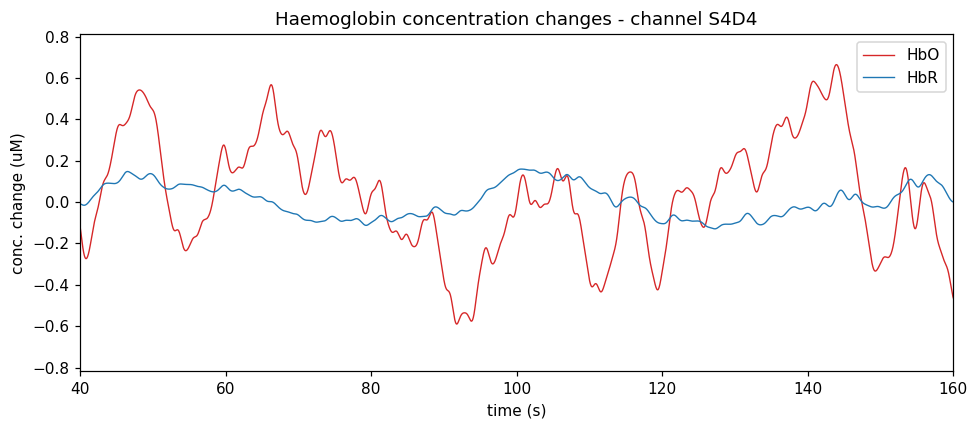

In [8]:
dpf = xr.DataArray([6.0, 6.0], dims=["wavelength"],
                   coords={"wavelength": [690.0, 830.0]})
conc = cw.od2conc(od_filt, geo3d, dpf, spectrum="prahl")
conc_uM = conc.pint.to("micromolar")
print("conc dims:", conc.dims, "chromophores:", list(conc.chromo.values))

hbo = conc_uM.sel(channel=demo_ch, chromo="HbO").pint.magnitude
hbr = conc_uM.sel(channel=demo_ch, chromo="HbR").pint.magnitude
fig, ax = plt.subplots()
ax.plot(conc.time.values, hbo, color="tab:red", lw=0.9, label="HbO")
ax.plot(conc.time.values, hbr, color="tab:blue", lw=0.9, label="HbR")
ax.set_xlim(40, 160)
ax.set_xlabel("time (s)"); ax.set_ylabel("conc. change (uM)")
ax.set_title(f"Haemoglobin concentration changes - channel {demo_ch}")
ax.legend(); plt.tight_layout(); plt.show()

## Takeaways

- **Intensity -> OD -> HbO/HbR** is the core fNIRS conversion (modified
  Beer-Lambert law).
- **Quality control** (SCI, SNR) drops poorly-coupled channels before analysis.
- **TDDR** removes motion spikes parameter-free; a **band-pass** isolates the
  haemodynamic band.
- The result is a clean **HbO/HbR** time course per channel - but in resting
  data there is no task, so no evoked response to see yet.

**Next - NB3:** use files with a *known* synthetic response added, and recover
it with **block averaging** and a **GLM** - the heart of task-based fNIRS
analysis.